In [23]:
import tarfile
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from fairchem.core.datasets import AseDBDataset
import collections
from tqdm import tqdm
import pandas as pd

In [17]:
omol_path = "../data/OMat24/"
output_path = os.path.join(omol_path, "output")

if len(os.listdir(output_path)) == 0:
    with tarfile.open(omol_path+"omat24_1M_251210.tar", "r") as tar:
        tar.extractall(path=output_path)

In [20]:
omol_path = "../data/OMat24/output"
splits = ["train", "val", "test"]

sub_folders = [
    "aimd-from-PBE-1000-npt", "aimd-from-PBE-1000-nvt",
    "aimd-from-PBE-3000-npt", "aimd-from-PBE-3000-nvt",
    "rattled-300-subsampled", "rattled-300",
    "rattled-500-subsampled", "rattled-500",
    "rattled-1000-subsampled", "rattled-1000",
    "rattled-relax"
]

datasets = {}

for split in splits:
    split_dir = os.path.join(omol_path, split)
    
    dataset_paths = []
    for sub in sub_folders:
        potential_path = os.path.join(split_dir, sub, f"{split}.aselmdb")
        dataset_paths.append(potential_path)

    datasets[split] = AseDBDataset(config={"src": dataset_paths})
    print(f"{split.capitalize()} dataset oprettet med {len(datasets[split])} entries.")

train_dataset = datasets.get("train")
val_dataset = datasets.get("val")
test_dataset = datasets.get("test")

Train dataset oprettet med 1009850 entries.
Val dataset oprettet med 107732 entries.
Test dataset oprettet med 53727 entries.


In [21]:
def extract_metadata(dataset):
    data = []
    for i in tqdm(range(len(dataset)), desc=f"Processing {dataset.name} dataset"):
        atoms = dataset.get_atoms(i)
        info = atoms.info

        atomic_numbers = atoms.get_atomic_numbers().tolist()
        symbols = atoms.get_chemical_symbols()
        num_atoms = len(atoms)

        row = {
            "atomic_numbers": atomic_numbers,
            "symbols": symbols,
            "num_atoms": num_atoms,
            "calc_id": info.get("calc_id"),
            "task_type": info.get("task_type"),
            "prototype_label": info.get("prototype_label"),
            "energy_corrected_mp2020": info.get("energy_corrected_mp2020"),
        }
        data.append(row)
    return pd.DataFrame(data)

train_dataset.name = "train"
val_dataset.name = "val"
test_dataset.name = "test"

train_df = extract_metadata(train_dataset)
val_df = extract_metadata(val_dataset)
test_df = extract_metadata(test_dataset)

print("\nTrain DataFrame head:")
print(train_df.head())
print("\nValidation DataFrame head:")
print(val_df.head())
print("\nTest DataFrame head:")
print(test_df.head())

Processing test dataset: 100%|██████████| 53727/53727 [00:04<00:00, 10793.16it/s]


Train DataFrame head:
                                      atomic_numbers  \
0                                   [81, 81, 80, 16]   
1                                   [19, 21, 44, 44]   
2                                   [24, 24, 26, 47]   
3  [68, 68, 25, 25, 25, 25, 25, 25, 25, 25, 25, 2...   
4   [59, 59, 60, 60, 60, 62, 62, 62, 62, 62, 62, 67]   

                                             symbols  num_atoms  \
0                                    [Tl, Tl, Hg, S]          4   
1                                    [K, Sc, Ru, Ru]          4   
2                                   [Cr, Cr, Fe, Ag]          4   
3  [Er, Er, Mn, Mn, Mn, Mn, Mn, Mn, Mn, Mn, Mn, M...         22   
4   [Pr, Pr, Nd, Nd, Nd, Sm, Sm, Sm, Sm, Sm, Sm, Ho]         12   

                  calc_id           task_type  \
0  aimd-from-PBE-1000-npt  Molecular Dynamics   
1  aimd-from-PBE-1000-npt  Molecular Dynamics   
2  aimd-from-PBE-1000-npt  Molecular Dynamics   
3  aimd-from-PBE-1000-npt  Molecular Dyna

/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_39772/3917601130.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dataset_labels, y=dataset_sizes, palette='viridis')


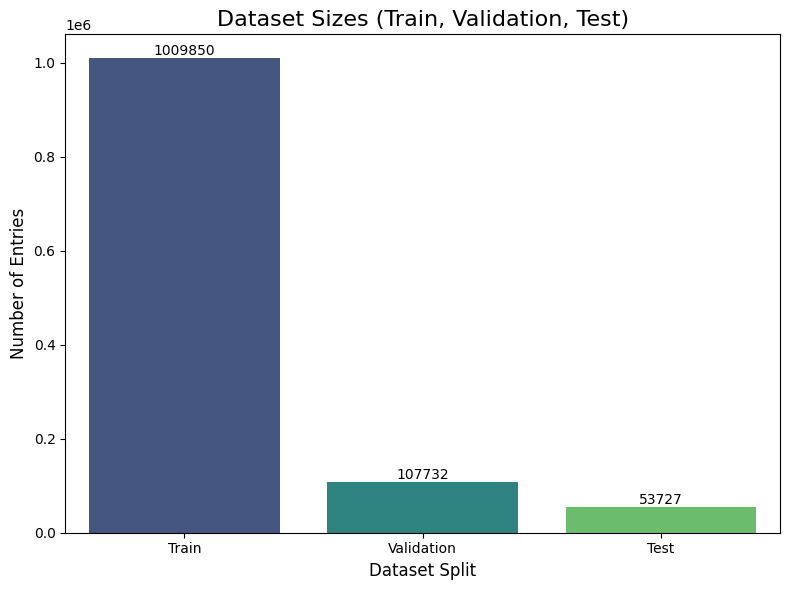

In [22]:
# Get the lengths of the DataFrames
dataset_sizes = [len(train_df), len(val_df), len(test_df)]

# Create labels for the datasets
dataset_labels = ['Train', 'Validation', 'Test']

# Create the bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x=dataset_labels, y=dataset_sizes, palette='viridis')

# Add title and labels
plt.title('Dataset Sizes (Train, Validation, Test)', fontsize=16)
plt.xlabel('Dataset Split', fontsize=12)
plt.ylabel('Number of Entries', fontsize=12)

# Add the number of entries on top of each bar
for index, value in enumerate(dataset_sizes):
    plt.text(index, value + 1000, str(value), ha='center', va='bottom') # Adjust offset for better visibility

plt.tight_layout()
plt.show()

In [24]:
def get_element_counts(df):
    all_symbols = [symbol for sublist in df['symbols'] for symbol in sublist]
    element_counts = collections.Counter(all_symbols)
    return pd.Series(element_counts).sort_values(ascending=False)

# Apply the function to each DataFrame
train_element_counts = get_element_counts(train_df)
val_element_counts = get_element_counts(val_df)
test_element_counts = get_element_counts(test_df)

print("Top 10 elements in Train Dataset:")
print(train_element_counts.head(10))
print(
"\nTop 10 elements in Validation Dataset:")
print(val_element_counts.head(10))
print(
"\nTop 10 elements in Test Dataset:")
print(test_element_counts.head(10))

Top 10 elements in Train Dataset:
O     743899
Se    458778
S     398275
Te    385910
Li    373646
Hg    371827
Pd    367587
La    362988
Cl    362557
Au    361268
dtype: int64

Top 10 elements in Validation Dataset:
O     79713
Se    49832
S     43957
Li    42135
Te    41408
Hg    40823
Au    39244
Cd    38283
In    38283
La    38231
dtype: int64

Top 10 elements in Test Dataset:
O     54911
Al    34674
In    24353
Si    23063
Se    22996
S     22677
Ga    21826
Ge    21783
Cu    20864
Ni    19783
dtype: int64


/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_39772/1187905103.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_element_counts.head(10).index, y=train_element_counts.head(10).values, ax=axes[0], palette='viridis')
/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_39772/1187905103.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=val_element_counts.head(10).index, y=val_element_counts.head(10).values, ax=axes[1], palette='viridis')
/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_39772/1187905103.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

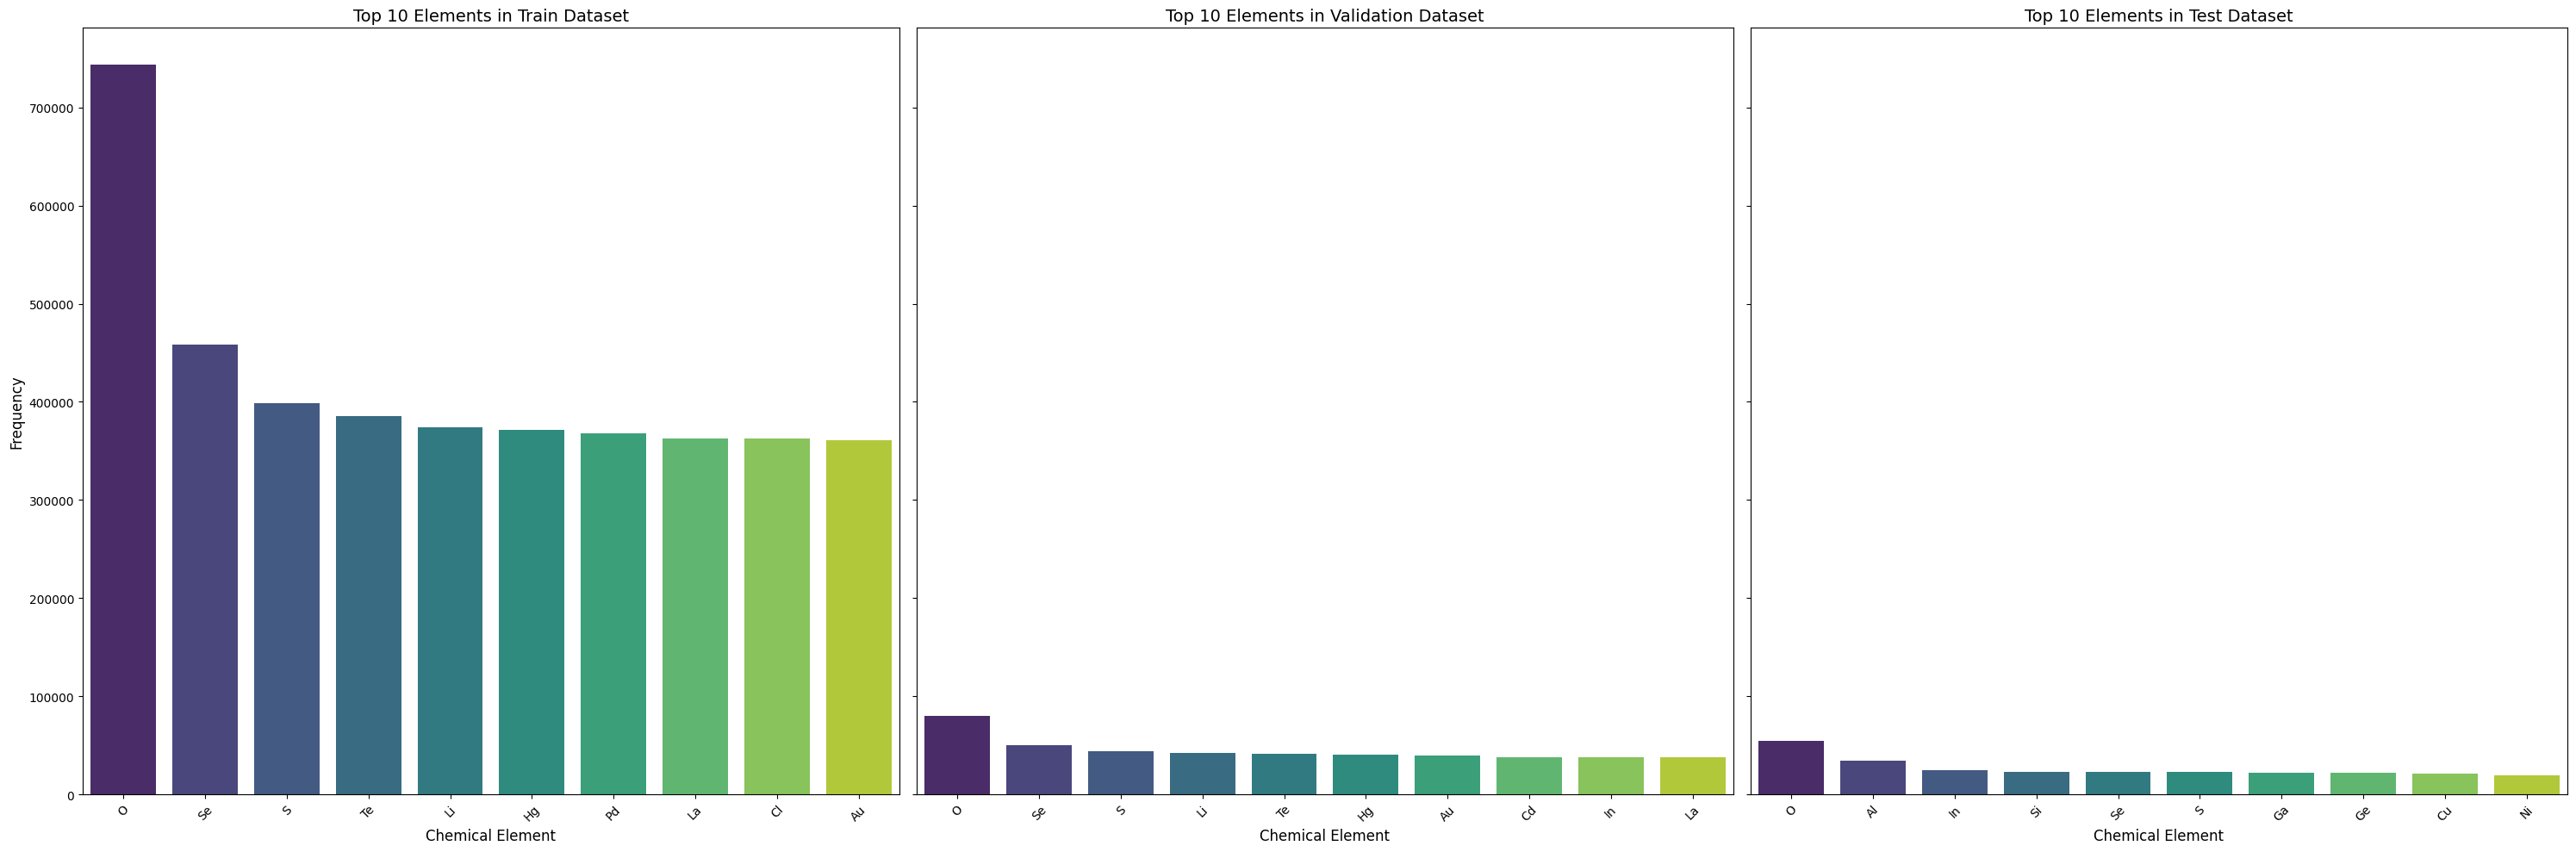

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(30, 10), sharey=True)

# Plot for Train Dataset
sns.barplot(x=train_element_counts.head(10).index, y=train_element_counts.head(10).values, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Elements in Train Dataset', fontsize=14)
axes[0].set_xlabel('Chemical Element', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Plot for Validation Dataset
sns.barplot(x=val_element_counts.head(10).index, y=val_element_counts.head(10).values, ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Elements in Validation Dataset', fontsize=14)
axes[1].set_xlabel('Chemical Element', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Plot for Test Dataset
sns.barplot(x=test_element_counts.head(10).index, y=test_element_counts.head(10).values, ax=axes[2], palette='viridis')
axes[2].set_title('Top 10 Elements in Test Dataset', fontsize=14)
axes[2].set_xlabel('Chemical Element', fontsize=12)
axes[2].set_ylabel('Frequency', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Task Type Distribution in Train Dataset:
task_type
Molecular Dynamics        551373
Static                    357934
Structure Optimization    100543
Name: count, dtype: int64

Task Type Distribution in Validation Dataset:
task_type
Molecular Dynamics        58826
Static                    38910
Structure Optimization     9996
Name: count, dtype: int64

Task Type Distribution in Test Dataset:
task_type
Molecular Dynamics        29679
Static                    19677
Structure Optimization     4371
Name: count, dtype: int64


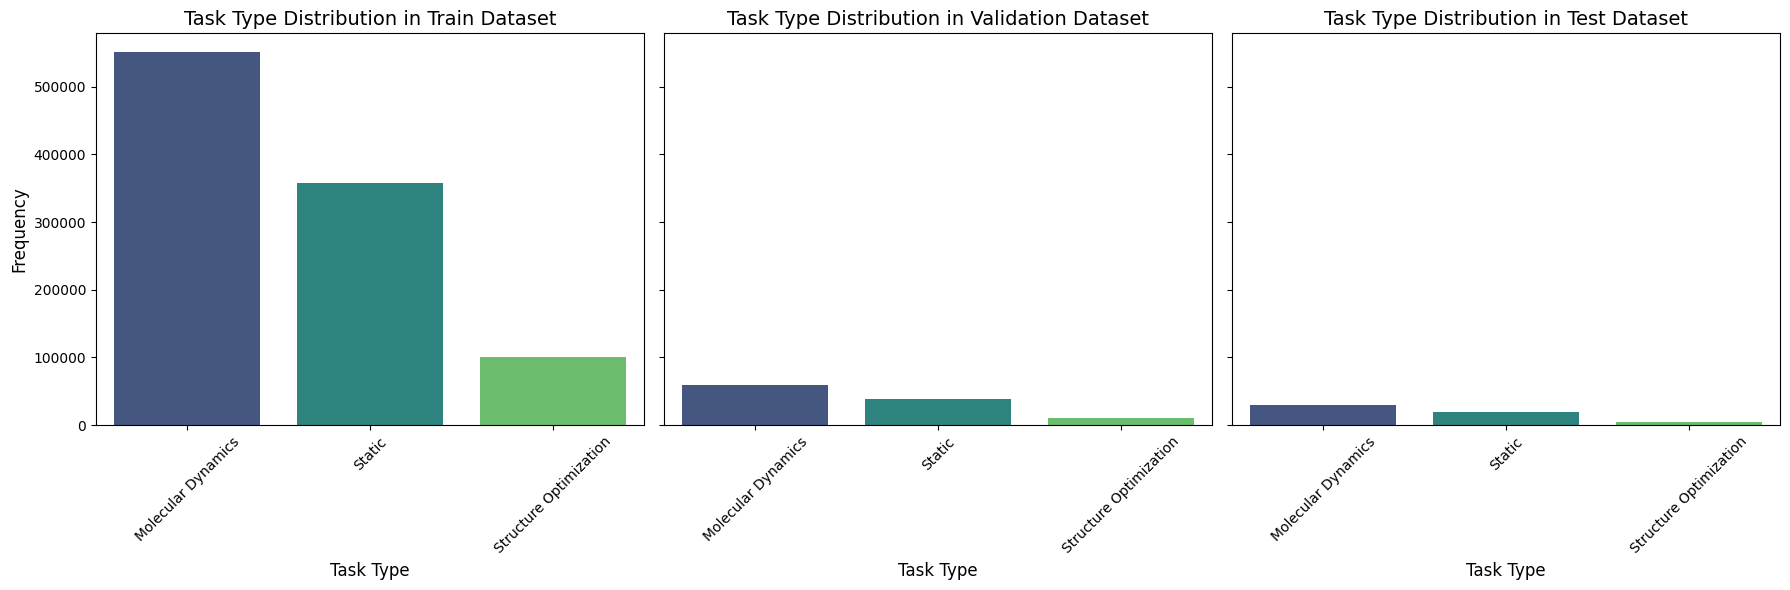

In [29]:
def get_task_type_counts(df):
    task_type_counts = df['task_type'].value_counts()
    return task_type_counts.sort_values(ascending=False)

# Apply the function to each DataFrame
train_task_type_counts = get_task_type_counts(train_df)
val_task_type_counts = get_task_type_counts(val_df)
test_task_type_counts = get_task_type_counts(test_df)

print("Task Type Distribution in Train Dataset:")
print(train_task_type_counts)
print("\nTask Type Distribution in Validation Dataset:")
print(val_task_type_counts)
print("\nTask Type Distribution in Test Dataset:")
print(test_task_type_counts)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Plot for Train Dataset
sns.barplot(x=train_task_type_counts.index, y=train_task_type_counts.values, ax=axes[0], palette='viridis', hue=train_task_type_counts.index, legend=False)
axes[0].set_title('Task Type Distribution in Train Dataset', fontsize=14)
axes[0].set_xlabel('Task Type', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Plot for Validation Dataset
sns.barplot(x=val_task_type_counts.index, y=val_task_type_counts.values, ax=axes[1], palette='viridis', hue=val_task_type_counts.index, legend=False)
axes[1].set_title('Task Type Distribution in Validation Dataset', fontsize=14)
axes[1].set_xlabel('Task Type', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Plot for Test Dataset
sns.barplot(x=test_task_type_counts.index, y=test_task_type_counts.values, ax=axes[2], palette='viridis', hue=test_task_type_counts.index, legend=False)
axes[2].set_title('Task Type Distribution in Test Dataset', fontsize=14)
axes[2].set_xlabel('Task Type', fontsize=12)
axes[2].set_ylabel('Frequency', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [30]:
print("Descriptive statistics for 'energy_corrected_mp2020' in Train Dataset:")
print(train_df['energy_corrected_mp2020'].describe())

print("\nDescriptive statistics for 'energy_corrected_mp2020' in Validation Dataset:")
print(val_df['energy_corrected_mp2020'].describe())

print("\nDescriptive statistics for 'energy_corrected_mp2020' in Test Dataset:")
print(test_df['energy_corrected_mp2020'].describe())

Descriptive statistics for 'energy_corrected_mp2020' in Train Dataset:
count    980632.000000
mean        -84.420663
std         106.453834
min       -1369.815429
25%         -82.586333
50%         -47.741246
75%         -26.473246
max        1474.100523
Name: energy_corrected_mp2020, dtype: float64

Descriptive statistics for 'energy_corrected_mp2020' in Validation Dataset:
count    104643.000000
mean        -85.195642
std         106.953212
min       -1081.488514
25%         -83.310194
50%         -48.307374
75%         -26.915182
max         464.202550
Name: energy_corrected_mp2020, dtype: float64

Descriptive statistics for 'energy_corrected_mp2020' in Test Dataset:
count    51935.000000
mean       -91.194202
std        114.819409
min       -997.677260
25%        -78.886974
50%        -53.790435
75%        -35.957751
max        865.401205
Name: energy_corrected_mp2020, dtype: float64


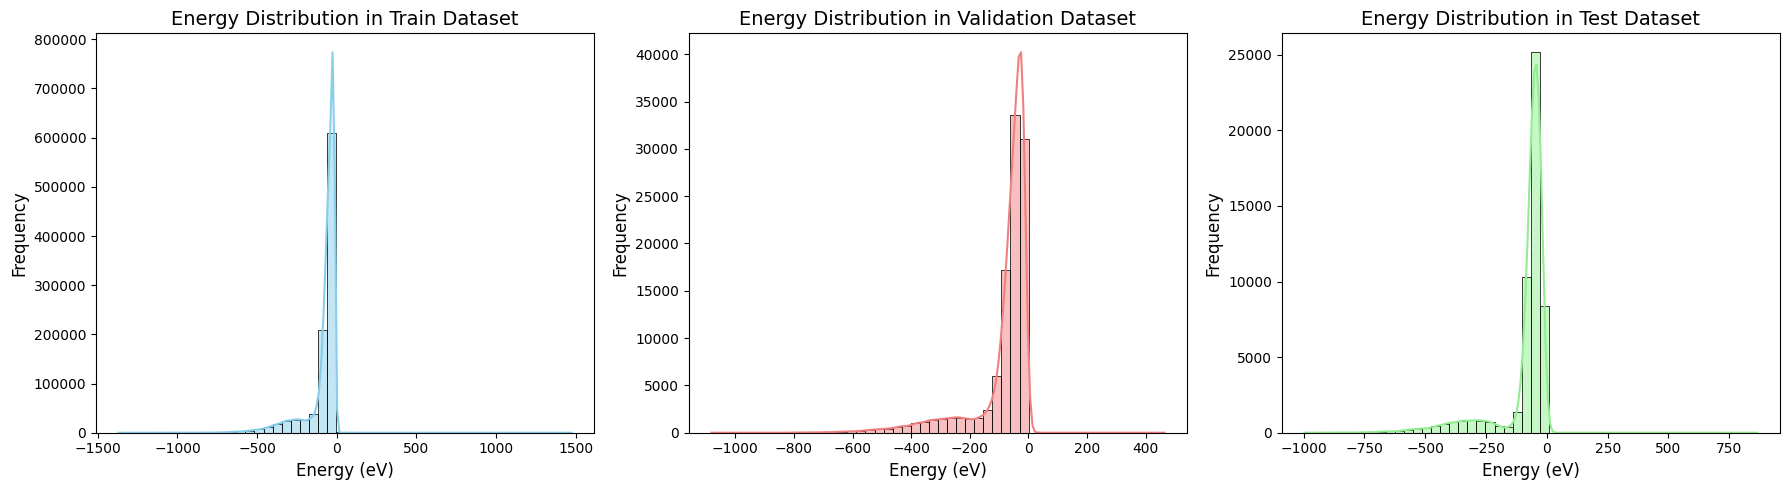

In [31]:
plt.figure(figsize=(18, 5))

# Plot for Train Dataset
plt.subplot(1, 3, 1)
sns.histplot(train_df['energy_corrected_mp2020'].dropna(), bins=50, kde=True, color='skyblue')
plt.title('Energy Distribution in Train Dataset', fontsize=14)
plt.xlabel('Energy (eV)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Plot for Validation Dataset
plt.subplot(1, 3, 2)
sns.histplot(val_df['energy_corrected_mp2020'].dropna(), bins=50, kde=True, color='lightcoral')
plt.title('Energy Distribution in Validation Dataset', fontsize=14)
plt.xlabel('Energy (eV)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Plot for Test Dataset
plt.subplot(1, 3, 3)
sns.histplot(test_df['energy_corrected_mp2020'].dropna(), bins=50, kde=True, color='lightgreen')
plt.title('Energy Distribution in Test Dataset', fontsize=14)
plt.xlabel('Energy (eV)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

*   **Dataset Sizes:** The `train` dataset is substantially larger with 1,009,850 entries, followed by the `validation` dataset with 107,732 entries, and the `test` dataset with 53,727 entries.
*   **Element Distribution:**
    *   The `train` and `validation` datasets show similar top 10 elemental compositions, heavily featuring O, Se, S, Te, and Li.
    *   The `test` dataset, however, exhibits a notably different top 10 composition, including elements like Al, In, Si, Ga, Ge, Cu, and Ni, which are less prominent in the other two sets. This suggests potential differences in material compositions represented in the test set.
*   **Calculation ID Distribution:** All three datasets (`train`, `validation`, and `test`) show a consistent pattern in their most frequent `calc_id` types. The top IDs across all splits are predominantly `aimd-from-PBE-1000-npt`, `aimd-from-PBE-1000-nvt`, `rattled-1000`, and `rattled-relax`.
*   **Task Type Distribution:** The distribution of `task_type` is remarkably consistent across all splits. 'Molecular Dynamics' is the most frequent type (e.g., 551,373 in train), followed by 'Static' (e.g., 357,934 in train), and then 'Structure Optimization' (e.g., 100,543 in train), maintaining similar proportions in validation and test sets.
*   **Prototype Label Distribution:** The distribution of `prototype_label` varies significantly across the splits. The `train` dataset shows a few highly dominant prototype labels (e.g., `AB_aP12_1_6a_6a:B-C` with 194 occurrences), whereas the `validation` and `test` datasets exhibit a flatter distribution for their top labels, indicating a broader range of less frequently repeated prototypes in these sets.
*   **Energy Distribution:** The `energy_corrected_mp2020` distributions across all three datasets (train, validation, test) are visually similar, characterized by a primary peak and a general spread of energy values. The descriptive statistics show comparable means (e.g., train: -84.42 eV, val: -85.20 eV, test: -91.19 eV) and standard deviations (e.g., train: 106.45 eV, val: 106.95 eV, test: 114.82 eV).

### Insights or Next Steps

*   **Address Test Set Discrepancy:** The significant difference in the top elemental composition and prototype label distribution of the `test` set compared to `train` and `validation` sets warrants further investigation. This could impact model generalization performance if the `test` set contains novel chemical environments not adequately represented in the training data. Consider techniques like stratified sampling for future dataset splits to ensure better representation of diverse elements and prototypes.
*   **Leverage Consistent Task/Calc Types:** The consistent distribution of `calc_id` and `task_type` across all datasets is a positive characteristic, suggesting that models trained on this data should be exposed to similar types of calculations and tasks during evaluation.
